In [2]:
import boto3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import io
import json
import os
from fredapi import Fred
from datetime import datetime

# Load FX rates from Athena (we'll align macro data to these dates)
def query_athena(query, database='fx_rates_db', region='us-east-2'):
    athena = boto3.client('athena', region_name=region)
    s3 = boto3.client('s3', region_name=region)
    output_location = 's3://fx-rates-ninpar/athena-results/'
    
    response = athena.start_query_execution(
        QueryString=query,
        QueryExecutionContext={'Database': database},
        ResultConfiguration={'OutputLocation': output_location}
    )
    query_id = response['QueryExecutionId']
    
    while True:
        status = athena.get_query_execution(QueryExecutionId=query_id)
        state = status['QueryExecution']['Status']['State']
        if state in ['SUCCEEDED', 'FAILED', 'CANCELLED']:
            break
        time.sleep(1)
    
    if state != 'SUCCEEDED':
        raise Exception(f"Query failed: {status['QueryExecution']['Status'].get('StateChangeReason')}")
    
    result_location = status['QueryExecution']['ResultConfiguration']['OutputLocation']
    bucket = result_location.split('/')[2]
    key = '/'.join(result_location.split('/')[3:])
    obj = s3.get_object(Bucket=bucket, Key=key)
    return pd.read_csv(io.BytesIO(obj['Body'].read()))

df_fx = query_athena("""
    SELECT date, rates.inr AS usd_inr, rates.eur AS usd_eur, 
           rates.gbp AS usd_gbp, rates.mxn AS usd_mxn, rates.php AS usd_php
    FROM fx_rates_db.usd
    ORDER BY date ASC
""")
df_fx['date'] = pd.to_datetime(df_fx['date'])
df_fx = df_fx.set_index('date').sort_index()

print(f"FX data loaded: {len(df_fx)} trading days")
print(f"Date range: {df_fx.index.min()} to {df_fx.index.max()}")

FX data loaded: 281 trading days
Date range: 2025-04-29 00:00:00 to 2026-06-05 00:00:00


In [3]:
# Replace with your actual key (or load from environment variable)
FRED_API_KEY = os.getenv('FED_API_KEY')
fred = Fred(api_key=FRED_API_KEY)

# Test the connection
test = fred.get_series('DFF', observation_start='2024-01-01', observation_end='2024-01-10')
print(f"FRED connection working. Sample data:\n{test}")

FRED connection working. Sample data:
2024-01-01    5.33
2024-01-02    5.33
2024-01-03    5.33
2024-01-04    5.33
2024-01-05    5.33
2024-01-06    5.33
2024-01-07    5.33
2024-01-08    5.33
2024-01-09    5.33
2024-01-10    5.33
dtype: float64


In [9]:
# Macro series to fetch from FRED (US-only — non-US comes from BIS)
fred_series = {
    # Interest rates (US)
    'DFF':     ('fed_funds_rate',    'Federal Funds Rate (daily)'),
    'DGS2':    ('us_2y_yield',       'US 2-Year Treasury Yield'),
    'DGS10':   ('us_10y_yield',      'US 10-Year Treasury Yield'),
    
    # Risk and dollar strength (US-centric, global indicators)
    'VIXCLS':  ('vix',               'VIX Volatility Index'),
    'DTWEXBGS':('dxy_broad',         'Trade-Weighted USD Index (Broad)'),
    
    # Inflation
    'CPIAUCSL':('us_cpi',            'US CPI (monthly, all items)'),
    
    # Yield spreads
    'T10Y2Y':  ('yield_curve_slope', 'US 10Y - 2Y Spread'),
}

print(f"Will fetch {len(fred_series)} US-focused series from FRED")
print("(Non-US rates come from BIS via Cell 4.5)\n")
for sid, (name, desc) in fred_series.items():
    print(f"  {sid:<15} → {name} ({desc})")

Will fetch 7 US-focused series from FRED
(Non-US rates come from BIS via Cell 4.5)

  DFF             → fed_funds_rate (Federal Funds Rate (daily))
  DGS2            → us_2y_yield (US 2-Year Treasury Yield)
  DGS10           → us_10y_yield (US 10-Year Treasury Yield)
  VIXCLS          → vix (VIX Volatility Index)
  DTWEXBGS        → dxy_broad (Trade-Weighted USD Index (Broad))
  CPIAUCSL        → us_cpi (US CPI (monthly, all items))
  T10Y2Y          → yield_curve_slope (US 10Y - 2Y Spread)


In [10]:
# Use a wider date range than your FX data to allow for lags
start_date = '2024-01-01'
end_date = datetime.now().strftime('%Y-%m-%d')

macro_data = {}
failed_series = []

print(f"Fetching FRED data from {start_date} to {end_date}...\n")

for series_id, (name, desc) in fred_series.items():
    try:
        data = fred.get_series(
            series_id, 
            observation_start=start_date, 
            observation_end=end_date
        )
        macro_data[name] = data
        print(f"  ✓ {name}: {len(data)} observations")
    except Exception as e:
        failed_series.append(series_id)
        print(f"  ✗ {name} ({series_id}): {str(e)[:60]}")

# Combine into single dataframe
macro_df = pd.DataFrame(macro_data)
macro_df.index.name = 'date'

print(f"\nMacro dataframe shape: {macro_df.shape}")
print(f"Date range: {macro_df.index.min()} to {macro_df.index.max()}")

if failed_series:
    print(f"\nFailed series (may need different IDs): {failed_series}")

Fetching FRED data from 2024-01-01 to 2026-06-08...

  ✓ fed_funds_rate: 887 observations
  ✓ us_2y_yield: 635 observations
  ✓ us_10y_yield: 635 observations
  ✓ vix: 635 observations
  ✓ dxy_broad: 635 observations
  ✓ us_cpi: 28 observations
  ✓ yield_curve_slope: 636 observations

Macro dataframe shape: (888, 7)
Date range: 2024-01-01 00:00:00 to 2026-06-08 00:00:00


In [12]:
import requests
from io import StringIO

# BIS policy rates API endpoints
bis_urls = {
    'india':       "https://stats.bis.org/api/v2/data/dataflow/BIS/WS_CBPOL/1.0/M.IN?format=csv",
    'mexico':      "https://stats.bis.org/api/v2/data/dataflow/BIS/WS_CBPOL/1.0/M.MX?format=csv",
    'philippines': "https://stats.bis.org/api/v2/data/dataflow/BIS/WS_CBPOL/1.0/M.PH?format=csv",
    'uk':          "https://stats.bis.org/api/v2/data/dataflow/BIS/WS_CBPOL/1.0/M.GB?format=csv",
    'eurozone':    "https://stats.bis.org/api/v2/data/dataflow/BIS/WS_CBPOL/1.0/M.XM?format=csv",
}

print("Fetching BIS policy rates...\n")

foreign_rates_raw = {}

for country, url in bis_urls.items():
    try:
        response = requests.get(url, timeout=30)
        response.raise_for_status()
        df_country = pd.read_csv(StringIO(response.text))
        foreign_rates_raw[country] = df_country
        print(f"  ✓ {country:<15} {len(df_country)} observations, columns: {list(df_country.columns)[:5]}")
    except Exception as e:
        print(f"  ✗ {country}: {str(e)[:80]}")

# Inspect the first one to understand the structure
if foreign_rates_raw:
    first_country = list(foreign_rates_raw.keys())[0]
    print(f"\n=== Sample structure ({first_country}) ===")
    print(foreign_rates_raw[first_country].head())
    print(f"\nColumns: {list(foreign_rates_raw[first_country].columns)}")

Fetching BIS policy rates...

  ✓ india           963 observations, columns: ['FREQ', 'REF_AREA', 'UNIT_MEASURE', 'UNIT_MULT', 'TIME_FORMAT']
  ✓ mexico          331 observations, columns: ['FREQ', 'REF_AREA', 'UNIT_MEASURE', 'UNIT_MULT', 'TIME_FORMAT']
  ✓ philippines     475 observations, columns: ['FREQ', 'REF_AREA', 'UNIT_MEASURE', 'UNIT_MULT', 'TIME_FORMAT']
  ✓ uk              965 observations, columns: ['FREQ', 'REF_AREA', 'UNIT_MEASURE', 'UNIT_MULT', 'TIME_FORMAT']
  ✓ eurozone        329 observations, columns: ['FREQ', 'REF_AREA', 'UNIT_MEASURE', 'UNIT_MULT', 'TIME_FORMAT']

=== Sample structure (india) ===
  FREQ REF_AREA  UNIT_MEASURE  UNIT_MULT  TIME_FORMAT  \
0    M       IN           368          0          NaN   
1    M       IN           368          0          NaN   
2    M       IN           368          0          NaN   
3    M       IN           368          0          NaN   
4    M       IN           368          0          NaN   

                                 

In [13]:
# Parse BIS data into a clean dataframe
country_codes = {
    'india':       'IN',
    'mexico':      'MX', 
    'philippines': 'PH',
    'uk':          'GB',
    'eurozone':    'XM'
}

parsed_rates = {}

for country, raw_df in foreign_rates_raw.items():
    # Keep only the columns we need
    clean = raw_df[['TIME_PERIOD', 'OBS_VALUE']].copy()
    clean['TIME_PERIOD'] = pd.to_datetime(clean['TIME_PERIOD'])
    clean = clean.set_index('TIME_PERIOD').sort_index()
    clean.columns = [f'{country}_policy_rate']
    parsed_rates[country] = clean

# Combine into single dataframe
foreign_rates = pd.concat(parsed_rates.values(), axis=1)

print(f"Combined foreign rates shape: {foreign_rates.shape}")
print(f"Date range: {foreign_rates.index.min()} to {foreign_rates.index.max()}")
print(f"\nLast 5 rows (recent policy rates):")
print(foreign_rates.tail())

# Resample to business days and forward-fill
# Rates persist between policy decisions, so ffill is correct
foreign_rates = foreign_rates.resample('B').ffill()

# Align to FX dates
foreign_rates_aligned = foreign_rates.reindex(df_fx.index, method='ffill')

print(f"\nAfter alignment to FX dates: {foreign_rates_aligned.shape}")
print(f"Coverage check:")
for col in foreign_rates_aligned.columns:
    pct = foreign_rates_aligned[col].notna().sum() / len(foreign_rates_aligned) * 100
    print(f"  {col}: {pct:.0f}% coverage")

Combined foreign rates shape: (965, 5)
Date range: 1946-01-01 00:00:00 to 2026-05-01 00:00:00

Last 5 rows (recent policy rates):
             india_policy_rate  mexico_policy_rate  philippines_policy_rate  \
TIME_PERIOD                                                                   
2026-01-01                5.25                7.00                     4.50   
2026-02-01                5.25                7.00                     4.25   
2026-03-01                5.25                6.75                     4.25   
2026-04-01                 NaN                6.75                     4.50   
2026-05-01                 NaN                6.50                     4.50   

             uk_policy_rate  eurozone_policy_rate  
TIME_PERIOD                                        
2026-01-01             3.75                   2.0  
2026-02-01             3.75                   2.0  
2026-03-01             3.75                   2.0  
2026-04-01             3.75                   2.0  
2026

In [15]:
# Check coverage and missing data — both FRED and BIS
print("=== FRED Data Coverage ===\n")
for col in macro_df.columns:
    non_null = macro_df[col].notna().sum()
    total = len(macro_df)
    pct = non_null / total * 100
    print(f"  {col:<25} {non_null:>4}/{total} observations ({pct:.0f}%)")

print(f"\n=== BIS Foreign Rates Coverage (after business-day alignment) ===\n")
for col in foreign_rates_aligned.columns:
    non_null = foreign_rates_aligned[col].notna().sum()
    total = len(foreign_rates_aligned)
    pct = non_null / total * 100
    print(f"  {col:<28} {non_null:>4}/{total} observations ({pct:.0f}%)")

print(f"\n=== Frequency check ===\n")
for col in ['fed_funds_rate', 'us_10y_yield', 'vix', 'us_cpi']:
    if col in macro_df.columns:
        series = macro_df[col].dropna()
        if len(series) > 1:
            gaps = series.index.to_series().diff().dropna()
            mode_gap = gaps.mode().iloc[0] if len(gaps.mode()) > 0 else 'unknown'
            print(f"  {col}: typical gap = {mode_gap}")

# BIS data is monthly originally, so check raw foreign_rates (not aligned)
print()
for col in foreign_rates.columns:
    series = foreign_rates[col].dropna()
    if len(series) > 1:
        # Show actual data freq from raw monthly data
        unique_dates = series.index.unique()
        print(f"  {col}: monthly source data, {len(unique_dates)} unique observations")

=== FRED Data Coverage ===

  fed_funds_rate             887/888 observations (100%)
  us_2y_yield                607/888 observations (68%)
  us_10y_yield               607/888 observations (68%)
  vix                        627/888 observations (71%)
  dxy_broad                  609/888 observations (69%)
  us_cpi                      27/888 observations (3%)
  yield_curve_slope          608/888 observations (68%)

=== BIS Foreign Rates Coverage (after business-day alignment) ===

  india_policy_rate             237/281 observations (84%)
  mexico_policy_rate            281/281 observations (100%)
  philippines_policy_rate       281/281 observations (100%)
  uk_policy_rate                281/281 observations (100%)
  eurozone_policy_rate          281/281 observations (100%)

=== Frequency check ===

  fed_funds_rate: typical gap = 1 days 00:00:00
  us_10y_yield: typical gap = 1 days 00:00:00
  vix: typical gap = 1 days 00:00:00
  us_cpi: typical gap = 31 days 00:00:00

  india_policy

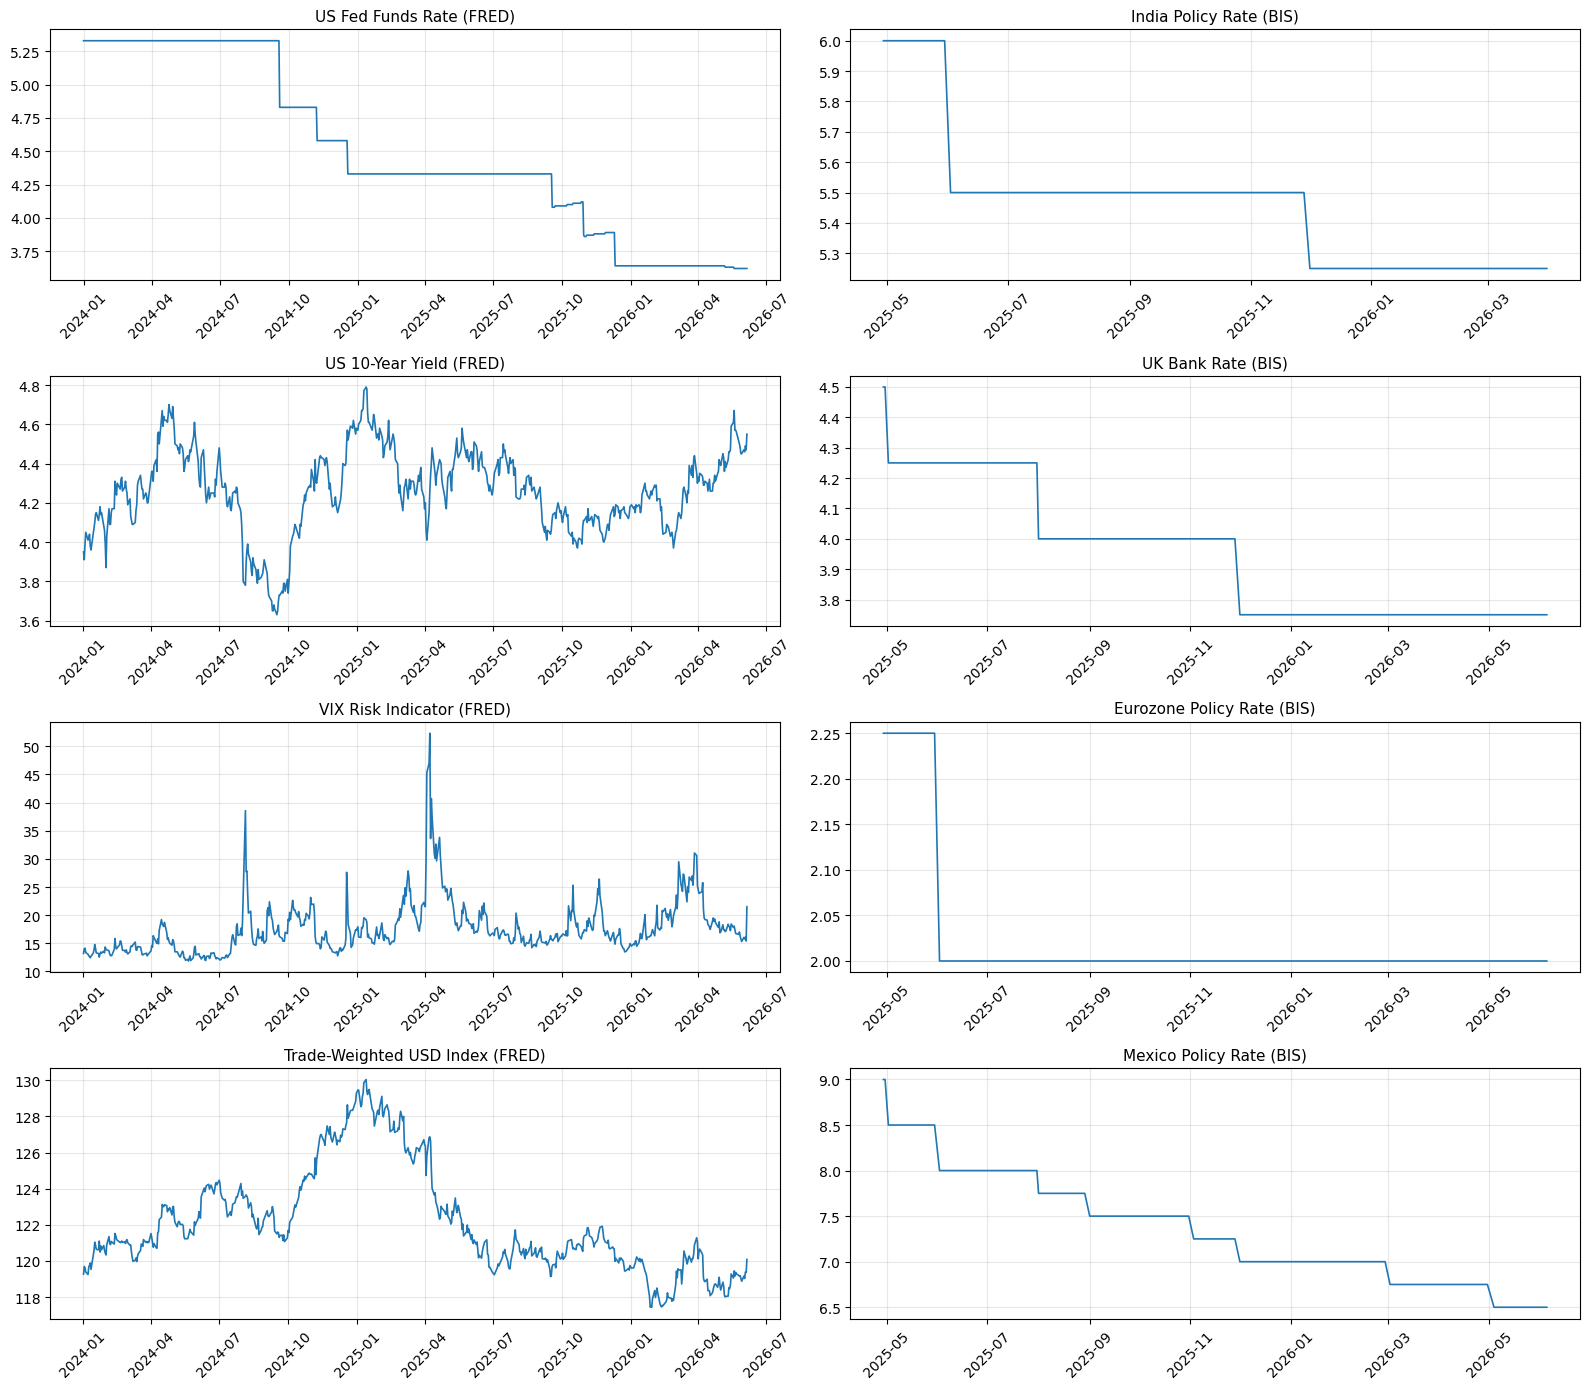

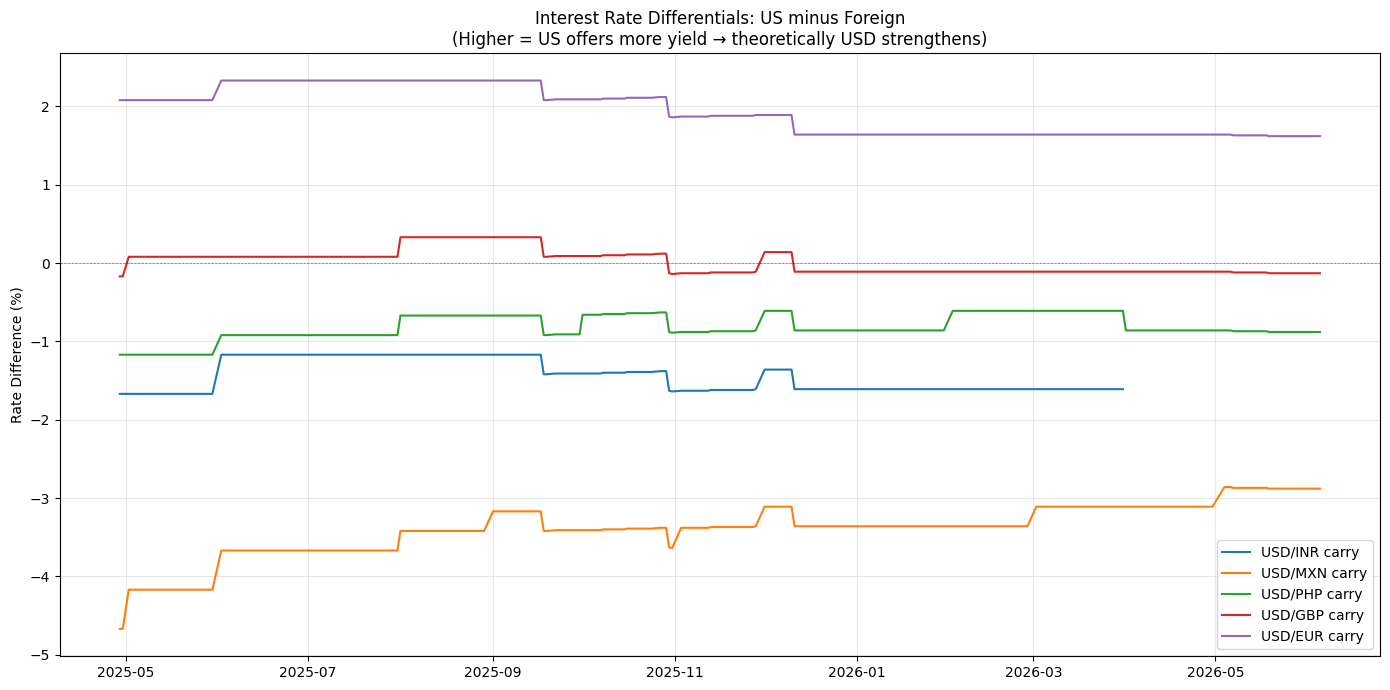

Rate differentials are key features for XGBoost.
Negative spread (e.g., US < India rate) = INR offers more yield → carry trade flows


In [16]:
fig, axes = plt.subplots(4, 2, figsize=(16, 14))
axes = axes.flatten()

# Mix of FRED and BIS sources
plot_specs = [
    (macro_df, 'fed_funds_rate',       'US Fed Funds Rate (FRED)'),
    (foreign_rates_aligned, 'india_policy_rate',     'India Policy Rate (BIS)'),
    (macro_df, 'us_10y_yield',         'US 10-Year Yield (FRED)'),
    (foreign_rates_aligned, 'uk_policy_rate',        'UK Bank Rate (BIS)'),
    (macro_df, 'vix',                   'VIX Risk Indicator (FRED)'),
    (foreign_rates_aligned, 'eurozone_policy_rate',  'Eurozone Policy Rate (BIS)'),
    (macro_df, 'dxy_broad',             'Trade-Weighted USD Index (FRED)'),
    (foreign_rates_aligned, 'mexico_policy_rate',    'Mexico Policy Rate (BIS)'),
]

for i, (source_df, col, title) in enumerate(plot_specs):
    if col in source_df.columns:
        series = source_df[col].dropna()
        if len(series) > 0:
            axes[i].plot(series.index, series.values, linewidth=1.2)
            axes[i].set_title(title, fontsize=11)
            axes[i].grid(True, alpha=0.3)
            axes[i].tick_params(axis='x', rotation=45)
    else:
        axes[i].text(0.5, 0.5, f'{col}\nnot available', 
                     ha='center', va='center', transform=axes[i].transAxes)
        axes[i].set_title(title, fontsize=11)

plt.tight_layout()
plt.savefig('macro_data_overview.png', dpi=150, bbox_inches='tight')
plt.show()

# Bonus plot: rate differentials over time (the carry trade signal)
fig, ax = plt.subplots(figsize=(14, 7))

diff_pairs = [
    ('india', 'USD/INR carry'),
    ('mexico', 'USD/MXN carry'),
    ('philippines', 'USD/PHP carry'),
    ('uk', 'USD/GBP carry'),
    ('eurozone', 'USD/EUR carry'),
]

us_rate_aligned = macro_df['fed_funds_rate'].resample('B').ffill().reindex(df_fx.index, method='ffill')

for country, label in diff_pairs:
    foreign_col = f'{country}_policy_rate'
    if foreign_col in foreign_rates_aligned.columns:
        diff = us_rate_aligned - foreign_rates_aligned[foreign_col]
        ax.plot(diff.index, diff.values, linewidth=1.5, label=label)

ax.axhline(0, color='black', linestyle='--', linewidth=0.5, alpha=0.5)
ax.set_title('Interest Rate Differentials: US minus Foreign\n(Higher = US offers more yield → theoretically USD strengthens)', fontsize=12)
ax.set_ylabel('Rate Difference (%)')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('rate_differentials.png', dpi=150, bbox_inches='tight')
plt.show()

print("Rate differentials are key features for XGBoost.")
print("Negative spread (e.g., US < India rate) = INR offers more yield → carry trade flows")

In [17]:
# Resample FRED data to business days
macro_aligned = macro_df.resample('B').ffill()
macro_aligned = macro_aligned.reindex(df_fx.index, method='ffill')

# Engineer features
features = pd.DataFrame(index=df_fx.index)

# US data from FRED
features['fed_funds_rate'] = macro_aligned['fed_funds_rate']
features['us_2y_yield'] = macro_aligned['us_2y_yield']
features['us_10y_yield'] = macro_aligned['us_10y_yield']
features['vix'] = macro_aligned['vix']
features['dxy_broad'] = macro_aligned['dxy_broad']
features['us_cpi'] = macro_aligned['us_cpi']
features['yield_slope'] = macro_aligned.get('yield_curve_slope', 
                                             features['us_10y_yield'] - features['us_2y_yield'])

# Foreign rates from BIS
for col in foreign_rates_aligned.columns:
    features[col] = foreign_rates_aligned[col]

# Rate differentials (US minus foreign — the carry signal)
features['us_india_rate_diff']       = features['fed_funds_rate'] - features['india_policy_rate']
features['us_mexico_rate_diff']      = features['fed_funds_rate'] - features['mexico_policy_rate']
features['us_philippines_rate_diff'] = features['fed_funds_rate'] - features['philippines_policy_rate']
features['us_uk_rate_diff']          = features['fed_funds_rate'] - features['uk_policy_rate']
features['us_eurozone_rate_diff']    = features['fed_funds_rate'] - features['eurozone_policy_rate']

# Change features
features['vix_change_5d'] = features['vix'].pct_change(5) * 100
features['vix_change_20d'] = features['vix'].pct_change(20) * 100
features['dxy_change_5d'] = features['dxy_broad'].pct_change(5) * 100
features['dxy_change_20d'] = features['dxy_broad'].pct_change(20) * 100
features['us_2y_change_5d'] = features['us_2y_yield'].diff(5)
features['us_2y_change_20d'] = features['us_2y_yield'].diff(20)

# Foreign rate change indicators (did they recently move?)
features['india_rate_changed_30d'] = (features['india_policy_rate'].diff(30) != 0).astype(int)
features['mexico_rate_changed_30d'] = (features['mexico_policy_rate'].diff(30) != 0).astype(int)
features['uk_rate_changed_30d'] = (features['uk_policy_rate'].diff(30) != 0).astype(int)

# Volatility regime flags
features['vix_above_20'] = (features['vix'] > 20).astype(int)
features['vix_above_30'] = (features['vix'] > 30).astype(int)

print(f"Feature dataframe shape: {features.shape}")
print(f"\nFeature categories:")
print(f"  US rates:           3 (fed_funds, 2Y, 10Y)")
print(f"  Risk/dollar:        2 (VIX, DXY)")
print(f"  Inflation:          1 (US CPI)")
print(f"  Foreign rates:      5 (IN, MX, PH, UK, EU)")
print(f"  Rate differentials: 5 (US vs each foreign)")
print(f"  Change features:    6 (5d/20d for VIX, DXY, 2Y)")
print(f"  Change indicators:  3 (foreign rate changes)")
print(f"  Regime flags:       2 (VIX > 20, > 30)")
print(f"  Yield curve:        1 (slope)")
print(f"  Total:             ~{features.shape[1]} features")

print(f"\nLast 5 rows:")
print(features.tail())

Feature dataframe shape: (281, 28)

Feature categories:
  US rates:           3 (fed_funds, 2Y, 10Y)
  Risk/dollar:        2 (VIX, DXY)
  Inflation:          1 (US CPI)
  Foreign rates:      5 (IN, MX, PH, UK, EU)
  Rate differentials: 5 (US vs each foreign)
  Change features:    6 (5d/20d for VIX, DXY, 2Y)
  Change indicators:  3 (foreign rate changes)
  Regime flags:       2 (VIX > 20, > 30)
  Yield curve:        1 (slope)
  Total:             ~28 features

Last 5 rows:
            fed_funds_rate  us_2y_yield  us_10y_yield    vix  dxy_broad  \
date                                                                      
2026-05-29            3.62         3.98          4.45  15.32   118.8783   
2026-06-01            3.62         4.05          4.47  16.05   119.1653   
2026-06-02            3.62         4.05          4.46  15.77   119.0359   
2026-06-03            3.62         4.08          4.49  16.06   119.3848   
2026-06-05            3.62         4.17          4.55  21.51   120.0831  

C:\Users\samik\AppData\Local\Temp\ipykernel_660\336420522.py:32: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  features['dxy_change_5d'] = features['dxy_broad'].pct_change(5) * 100
C:\Users\samik\AppData\Local\Temp\ipykernel_660\336420522.py:33: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  features['dxy_change_20d'] = features['dxy_broad'].pct_change(20) * 100


In [18]:
# Find where India data starts
india = foreign_rates_aligned['india_policy_rate']
first_valid = india.first_valid_index()
last_valid = india.last_valid_index()
print(f"India policy rate first valid: {first_valid}")
print(f"India policy rate last valid:  {last_valid}")
print(f"NaN count: {india.isna().sum()}")
print(f"Total: {len(india)}")

India policy rate first valid: 2025-04-29 00:00:00
India policy rate last valid:  2026-03-31 00:00:00
NaN count: 44
Total: 281


In [19]:
# Apply bfill + ffill to all foreign rate columns
foreign_cols = [c for c in features.columns if 'policy_rate' in c and c != 'us_cpi']

for col in foreign_cols:
    features[col] = features[col].fillna(method='bfill').fillna(method='ffill')

# Recompute differentials
features['us_india_rate_diff']       = features['fed_funds_rate'] - features['india_policy_rate']
features['us_mexico_rate_diff']      = features['fed_funds_rate'] - features['mexico_policy_rate']
features['us_philippines_rate_diff'] = features['fed_funds_rate'] - features['philippines_policy_rate']
features['us_uk_rate_diff']          = features['fed_funds_rate'] - features['uk_policy_rate']
features['us_eurozone_rate_diff']    = features['fed_funds_rate'] - features['eurozone_policy_rate']

# Verify
print("Coverage after backfill/forward-fill:\n")
for col in foreign_cols:
    pct = features[col].notna().sum() / len(features) * 100
    print(f"  {col:<28} {pct:.0f}%")

Coverage after backfill/forward-fill:

  india_policy_rate            100%
  mexico_policy_rate           100%
  philippines_policy_rate      100%
  uk_policy_rate               100%
  eurozone_policy_rate         100%


C:\Users\samik\AppData\Local\Temp\ipykernel_660\3659450380.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  features[col] = features[col].fillna(method='bfill').fillna(method='ffill')


In [23]:
# Drop us_cpi (only 5 observations — useless for correlation)
features_clean = features.drop(columns=['us_cpi'], errors='ignore')

# Check for constant columns (zero variance = can't correlate)
constant_cols = [c for c in features_clean.columns if features_clean[c].nunique() <= 1]
if constant_cols:
    print(f"Dropping constant columns: {constant_cols}")
    features_clean = features_clean.drop(columns=constant_cols)

# Compute correlations against FX returns
# pandas .corr() uses pairwise-complete observations automatically
combined = pd.concat([features_clean, fx_returns], axis=1)

print(f"Computing correlations on {len(combined)} rows...\n")

fx_cols = ['usd_inr', 'usd_eur', 'usd_gbp', 'usd_mxn', 'usd_php']
feature_cols = [c for c in features_clean.columns if c not in fx_cols]

# Pairwise correlation handles NaN automatically  
fx_correlations = combined[feature_cols + fx_cols].corr().loc[feature_cols, fx_cols]

print("=== Correlation: Macro Features vs FX Daily Returns ===\n")
print(fx_correlations.round(3).to_string())

print("\n=== Strongest correlations per pair ===\n")
for fx_col in fx_cols:
    sorted_corr = fx_correlations[fx_col].abs().sort_values(ascending=False)
    print(f"{fx_col.upper()}:")
    for feat in sorted_corr.head(5).index:
        val = fx_correlations.loc[feat, fx_col]
        print(f"  {feat:<28} corr = {val:>+.3f}")
    print()

print("Reality check: in FX literature, daily-return correlations with")
print("macro variables are typically 0.05-0.25 (weak). Values above 0.3")
print("for daily returns warrant skepticism — likely spurious or driven")
print("by a small number of extreme days.")

Computing correlations on 281 rows...

=== Correlation: Macro Features vs FX Daily Returns ===

                          usd_inr  usd_eur  usd_gbp  usd_mxn  usd_php
fed_funds_rate             -0.024   -0.036    0.004   -0.013   -0.004
us_2y_yield                 0.048    0.031    0.030    0.016    0.077
us_10y_yield                0.031    0.025    0.016    0.014    0.053
vix                         0.037    0.087    0.093    0.155    0.056
dxy_broad                   0.013    0.096    0.076    0.068    0.072
yield_slope                -0.063   -0.032   -0.050   -0.014   -0.094
india_policy_rate          -0.022    0.006    0.003   -0.001   -0.023
mexico_policy_rate         -0.021   -0.017    0.013   -0.012   -0.013
philippines_policy_rate    -0.010   -0.036   -0.011   -0.039   -0.001
uk_policy_rate             -0.019   -0.005    0.032   -0.004    0.020
eurozone_policy_rate       -0.014    0.016   -0.021   -0.007   -0.031
us_india_rate_diff         -0.014   -0.063    0.003   -0.019    

In [24]:
print("=== Actual Rate Differential Values ===\n")
print("US fed funds rate range:")
print(f"  Min: {features['fed_funds_rate'].min():.2f}%")
print(f"  Max: {features['fed_funds_rate'].max():.2f}%")
print(f"  Current: {features['fed_funds_rate'].iloc[-1]:.2f}%")
print()

for country in ['india', 'mexico', 'philippines', 'uk', 'eurozone']:
    rate_col = f'{country}_policy_rate'
    diff_col = f'us_{country}_rate_diff'
    
    if rate_col in features.columns:
        rate_min = features[rate_col].min()
        rate_max = features[rate_col].max()
        diff_min = features[diff_col].min()
        diff_max = features[diff_col].max()
        diff_current = features[diff_col].iloc[-1]
        diff_std = features[diff_col].std()
        
        print(f"{country.capitalize():<12} policy rate:  {rate_min:.2f}% to {rate_max:.2f}%")
        print(f"           differential:  {diff_min:+.2f}% to {diff_max:+.2f}% (current: {diff_current:+.2f}%)")
        print(f"           std dev of differential over time: {diff_std:.3f}%")
        print()

=== Actual Rate Differential Values ===

US fed funds rate range:
  Min: 3.62%
  Max: 4.33%
  Current: 3.62%

India        policy rate:  5.25% to 6.00%
           differential:  -1.67% to -1.17% (current: -1.63%)
           std dev of differential over time: 0.200%

Mexico       policy rate:  6.50% to 9.00%
           differential:  -4.67% to -2.86% (current: -2.88%)
           std dev of differential over time: 0.331%

Philippines  policy rate:  4.25% to 5.50%
           differential:  -1.17% to -0.61% (current: -0.88%)
           std dev of differential over time: 0.160%

Uk           policy rate:  3.75% to 4.50%
           differential:  -0.17% to +0.33% (current: -0.13%)
           std dev of differential over time: 0.152%

Eurozone     policy rate:  2.00% to 2.25%
           differential:  +1.62% to +2.33% (current: +1.62%)
           std dev of differential over time: 0.294%



In [25]:
# Test the differential against forward returns at multiple horizons
print("=== Differential predictive power at different horizons ===\n")

for col, country in [('usd_inr', 'india'), ('usd_eur', 'eurozone'),
                     ('usd_gbp', 'uk'), ('usd_mxn', 'mexico'),
                     ('usd_php', 'philippines')]:
    diff_col = f'us_{country}_rate_diff'
    
    print(f"{col.upper()} vs {diff_col}:")
    
    for horizon in [1, 5, 20, 60]:
        # Forward return: how much did rate change over next N days?
        forward_return = df_fx[col].pct_change(horizon).shift(-horizon)
        combined = pd.concat([features[diff_col], forward_return], axis=1).dropna()
        corr = combined.corr().iloc[0, 1] if len(combined) > 10 else None
        
        print(f"  {horizon:>3}-day forward returns: corr = {corr:+.3f}  (n={len(combined)})")
    print()

=== Differential predictive power at different horizons ===

USD_INR vs us_india_rate_diff:
    1-day forward returns: corr = +0.008  (n=280)
    5-day forward returns: corr = -0.027  (n=276)
   20-day forward returns: corr = -0.182  (n=261)
   60-day forward returns: corr = -0.394  (n=221)

USD_EUR vs us_eurozone_rate_diff:
    1-day forward returns: corr = -0.035  (n=280)
    5-day forward returns: corr = -0.079  (n=276)
   20-day forward returns: corr = -0.134  (n=261)
   60-day forward returns: corr = -0.223  (n=221)

USD_GBP vs us_uk_rate_diff:
    1-day forward returns: corr = -0.039  (n=280)
    5-day forward returns: corr = -0.007  (n=276)
   20-day forward returns: corr = +0.152  (n=261)
   60-day forward returns: corr = +0.507  (n=221)

USD_MXN vs us_mexico_rate_diff:
    1-day forward returns: corr = -0.001  (n=279)
    5-day forward returns: corr = +0.047  (n=275)
   20-day forward returns: corr = +0.091  (n=260)
   60-day forward returns: corr = +0.183  (n=220)

USD_PHP vs

In [26]:
# Save feature dataframe
features.to_csv('macro_features.csv')

# Also save to S3 alongside FX data
s3 = boto3.client('s3', region_name='us-east-2')

# Save as CSV to S3
csv_buffer = io.StringIO()
features.to_csv(csv_buffer)
s3.put_object(
    Bucket='fx-rates-ninpar',
    Key='macro/features.csv',
    Body=csv_buffer.getvalue()
)

print(f"Saved {len(features)} rows × {features.shape[1]} features")
print("Local: notebooks/macro_features.csv")
print("S3:    s3://fx-rates-ninpar/macro/features.csv")
print()
print("Notebooks 07 (Chronos-2) and 08 (XGBoost) will use this dataset")

Saved 281 rows × 28 features
Local: notebooks/macro_features.csv
S3:    s3://fx-rates-ninpar/macro/features.csv

Notebooks 07 (Chronos-2) and 08 (XGBoost) will use this dataset


In [27]:
print("=== Macro Data Summary ===\n")
print(f"Total trading days: {len(features)}")
print(f"Date range: {features.index.min()} to {features.index.max()}")
print(f"Features: {features.shape[1]}")
print()

print("Categories:")
print(f"  Interest rates (US):     3  (fed_funds, 2Y, 10Y)")
print(f"  Risk indicators:         1  (VIX)")  
print(f"  Dollar strength:         1  (DXY broad)")
print(f"  Inflation:               1  (US CPI)")
print(f"  Yield curve:             1  (slope)")
print(f"  Engineered changes:      6  (5d/20d changes for VIX, DXY, US 2Y)")

rate_diff_cols = [c for c in features.columns if 'rate_diff' in c]
print(f"  Rate differentials:      {len(rate_diff_cols)}  (US vs IN/EU/UK/MX)")

print(f"  Regime flags:            2  (VIX>20, VIX>30)")

print()
print("=== Distribution of key features ===\n")
key_features = ['fed_funds_rate', 'vix', 'dxy_broad', 'yield_slope', 'us_cpi']
print(features[key_features].describe().round(3).to_string())

=== Macro Data Summary ===

Total trading days: 281
Date range: 2025-04-29 00:00:00 to 2026-06-05 00:00:00
Features: 28

Categories:
  Interest rates (US):     3  (fed_funds, 2Y, 10Y)
  Risk indicators:         1  (VIX)
  Dollar strength:         1  (DXY broad)
  Inflation:               1  (US CPI)
  Yield curve:             1  (slope)
  Engineered changes:      6  (5d/20d changes for VIX, DXY, US 2Y)
  Rate differentials:      5  (US vs IN/EU/UK/MX)
  Regime flags:            2  (VIX>20, VIX>30)

=== Distribution of key features ===

       fed_funds_rate      vix  dxy_broad  yield_slope   us_cpi
count         281.000  281.000    271.000      271.000    5.000
mean            3.961   18.324    120.077        0.552  325.629
std             0.311    3.253      1.235        0.071    4.045
min             3.620   13.470    117.440        0.380  322.169
25%             3.640   16.250    119.288        0.505  323.291
50%             3.880   17.360    120.140        0.540  324.245
75%       